# **PART A: DATASET PREPARATION**

  
  1. Load Tiny Shakespeare
  2. Explore the dataset
  3. Convert text to lowercase
  4. Tokenize text
  5. Build vocabulary
  6. Create input sequences
  7. Pad sequences
  8. Split into training & validation data

In [32]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Embedding, SimpleRNN, Dense

In [2]:
# Import dataset library
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("Trelis/tiny-shakespeare")
print(dataset)

c:\Users\Akhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})


In [3]:
# First training sample
print(dataset["train"][0])

{'Text': "First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citizens, the patricians good.\nWhat authority surfeits on would relieve us: if they\nwould yield us but the superfluity, while it were\nwholesome, we might guess they relieved us humanely;\nbut they think we are too dear: the leanness that\nafflicts us, the object of our misery, is as an\ninventory to particularise their abundance; our\nsufferance is a gain to them Let us revenge this with\nour pikes, ere we become rakes: for the gods know I\nspeak this i

In [4]:
# Extract the first sample in Text column
sample_text = dataset["train"][0]['Text']
print(sample_text)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [5]:
# length of the sample
print("Number of characters:", len(sample_text))

Number of characters: 3131


In [6]:
# combines Text column into one large string
train_text = "\n".join(dataset["train"]["Text"])
test_text = "\n".join(dataset["test"]["Text"])

print("Training characters   :", len(train_text))
print("Test characters       :", len(test_text))

Training characters   : 1222825
Test characters       : 119068


In [7]:
def isupper_true():
    print("uppercase letters in training samples:", any(char.isupper() for char in train_text))
    print("uppercase letters in testing samples:", any(char.isupper() for char in test_text))
    
isupper_true()

uppercase letters in training samples: True
uppercase letters in testing samples: True


In [8]:
# converting to uppercase to lowercase
train_text = train_text.lower()
test_text = test_text.lower()

isupper_true()

uppercase letters in training samples: False
uppercase letters in testing samples: False


In [9]:
# Initialize the tokenizer
tokenizer = Tokenizer() 

# Fit ONLY on the training text
tokenizer.fit_on_texts([train_text])    # count all unique words,and creates a mapping dict

# Convert texts into numerical sequences
train_sequences = tokenizer.texts_to_sequences([train_text])
test_sequences = tokenizer.texts_to_sequences([test_text])

vocab_size = len(tokenizer.word_index) + 1 # index 0 reserved for padding
print("Vocabulary size:", vocab_size)

Vocabulary size: 11980


In [10]:
print("First 15 words in vocabulary:")
for word, index in list(tokenizer.word_index.items())[:15]:
    print(f'{word}: {index}')

First 15 words in vocabulary:
the: 1
and: 2
to: 3
i: 4
of: 5
my: 6
you: 7
a: 8
that: 9
in: 10
is: 11
not: 12
for: 13
with: 14
me: 15


In [11]:
print(type(train_sequences))
print("Number of sequences:", len(train_sequences[0]))

<class 'list'>
Number of sequences: 223886


In [12]:
print("First 20 token IDs:")
print(train_sequences[0][:20])

First 20 token IDs:
[79, 260, 149, 34, 875, 148, 650, 127, 15, 106, 35, 106, 106, 79, 260, 7, 41, 35, 1382, 347]


In [ ]:
input_sequences = []

# Choose a reasonable maximum window size (e.g., 50 words context)
# Change this number based on how much context you our model want to look at
WINDOW_SIZE = 50 

# one giant list of tokens
tokens = train_sequences[0] 

# Use a sliding window to generate sequences safely and instantly
for i in range(1, len(tokens)):
    # Start the slice at either 0 or the window limit
    start_idx = max(0, i + 1 - WINDOW_SIZE)
    sequence = tokens[start_idx : i + 1]
    input_sequences.append(sequence)

print("Number of input sequences:", len(input_sequences))
max_sequence_length = max(len(seq) for seq in input_sequences)
print("Maximum sequence length:", max_sequence_length)

Number of input sequences: 223885
Maximum sequence length: 50


In [15]:
# pad the sequences
input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

In [17]:
# seperate inputs and outputs
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (223885, 49)
y shape: (223885,)


In [20]:
print("Example input:", X[0])
print("Example target:", y[0])

Example input: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
 79]
Example target: 260


In [26]:
# Split into training and validation datasets
split_index = int(0.8 * len(X))

print("Training samples:", split_index)
print("Validation samples:", len(X) - split_index)

# Create training and validation sets
X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

# final dataset sizes
print("\nTraining input shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("Validation input shape:", X_val.shape)
print("Validation target shape:", y_val.shape)

Training samples: 179108
Validation samples: 44777

Training input shape: (179108, 49)
Training target shape: (179108,)
Validation input shape: (44777, 49)
Validation target shape: (44777,)


# **PART B — IMPLEMENTING THE RNN MODEL**

In [ ]:
# Define model parameters

embedding_dim = 128
rnn_units = 128 #  number of internal memory cells (neurons) inside the layer.

print("Vocabulary size:", vocab_size)
print("Maximum sequence length:", max_sequence_length)
print("Embedding dimension:", embedding_dim)
print("RNN units:", rnn_units)

Vocabulary size: 11980
Maximum sequence length: 50
Embedding dimension: 128
RNN units: 128


In [ ]:
# Build the model

model = Sequential([
    Input(shape=(max_sequence_length,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
    ),

    SimpleRNN(
        rnn_units 
    ),

    Dense(
        vocab_size,
        activation="softmax"
    )
])  

In [50]:
# compile the model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [51]:
# model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     1,533,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11980)          │     1,545,420 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,111,756 (11.87 MB)

 Trainable params: 3,111,756 (11.87 MB)

 Non-trainable params: 0 (0.00 B)

# **PART C: TRAINING AND EVALUATING THE RNN**

In [52]:
# Train the model
epochs = 10
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 122s 86ms/step - accuracy: 0.0499 - loss: 6.6753 - val_accuracy: 0.0682 - val_loss: 6.7638
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 134s 80ms/step - accuracy: 0.0875 - loss: 5.9826 - val_accuracy: 0.0795 - val_loss: 6.7461
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 117s 63ms/step - accuracy: 0.1061 - loss: 5.5925 - val_accuracy: 0.0842 - val_loss: 6.8215
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - accuracy: 0.1244 - loss: 5.2496 - val_accuracy: 0.0813 - val_loss: 6.9683
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.1463 - loss: 4.9324 - val_accuracy: 0.0801 - val_loss: 7.0796
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.1740 - loss: 4.6355 - val_accuracy: 0.0756 - val_loss: 7.2262
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 51s 36ms/step - accuracy: 0.2041 - loss: 4.3596 - val_accuracy: 0.0721 - val_loss: 7.3988
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 48s 34ms/step - accuracy: 0.236

In [53]:
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

print(f"Final Training Accuracy:, {train_accuracy[-1]:.2f}")
print(f"Final Validation Accuracy:, {val_accuracy[-1]:.2f}")

print(f"Final Training Loss:, {train_loss[-1]:.2f}")
print(f"Final Validation Loss:, {val_loss[-1]:.2f}")

Final Training Accuracy:, 0.30
Final Validation Accuracy:, 0.06
Final Training Loss:, 3.67
Final Validation Loss:, 7.81


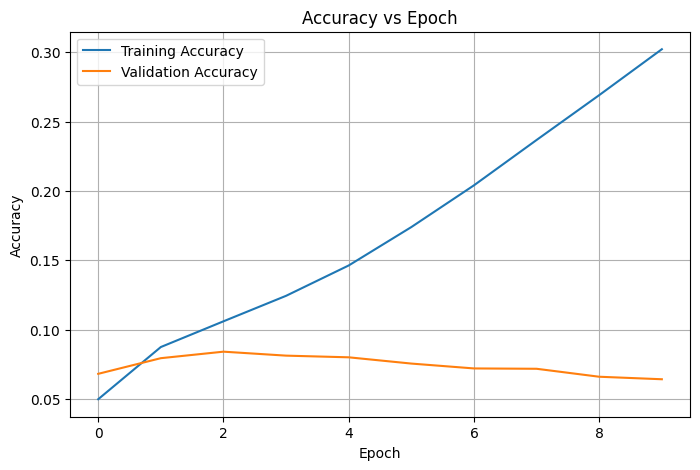

In [54]:
# Accuracy vs Epoch graph

plt.figure(figsize=(8, 5))
plt.plot(train_accuracy, label="Training Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

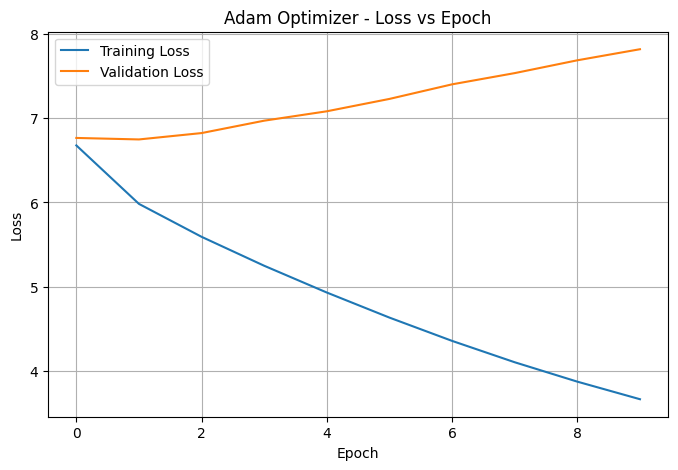

In [55]:
# Loss vs Epoch graph

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Adam Optimizer - Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# **PART D — TEXT GENERATION AND EXPERIMENT MANAGEMENT**

In [58]:
# Create the text-generation function

def generate_text(seed_text, next_words=20):
    
    generated_text = seed_text.lower()
    
    for _ in range(next_words):
        
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]
        
        token_list = token_list[-X_train.shape[1]:]
        
        token_list = np.array([token_list])
        
        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )
        
        predicted_index = np.argmax(
            predicted_probabilities[0]
        )

        predicted_word = tokenizer.sequences_to_texts([[predicted_index]])[0]

        if predicted_word == "":
            break
        
        generated_text += " " + predicted_word
    
    return generated_text

In [59]:
seed = "the king"

generated = generate_text(
    seed,
    next_words=20
)

print("Generated text:")
print(generated)

Generated text:
the king is dead and that i should be guiltless of the king and undertake to be a marvellous proper man a


In [60]:
# generate multiple samples
seeds = [
    "i love",
    "my lord",
    "to be",
    "i am",
    "the world"
]

for seed in seeds:
    print("\n" + "=" * 70)
    print("Seed:", seed)
    print("Generated:")
    print(generate_text(seed, next_words=20))


Seed: i love
Generated:
i love to thee and i will confess to thee and as i can tell you what news is this news sir

Seed: my lord
Generated:
my lord aumerle buckingham lord mayor and welcome to the king and signify to me and yet i fear not what i

Seed: to be
Generated:
to be pinched to the chameleon change shapes with proteus for advantages and leave the worst is worldly men he wore his

Seed: i am
Generated:
i am sorry that i mean to have a marvellous proper man i think you have not to the market place coriolanus

Seed: the world
Generated:
the world is cheered by the sun that i have bought the mansion of a love i mean to thee and honest


In [61]:
# Create a temperature-based generator\

def generate_text_temperature(seed_text, next_words=20, temperature=0.7):
    
    generated_text = seed_text.lower()

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        token_list = token_list[-X_train.shape[1]:]

        token_list = np.array([token_list])

        predictions = model.predict(
            token_list,
            verbose=0
        )[0]

        predictions = np.asarray(predictions).astype("float64")

        predictions = np.log(
            predictions + 1e-8
        ) / temperature

        probabilities = np.exp(predictions)

        probabilities = probabilities / np.sum(
            probabilities
        )

        predicted_index = np.random.choice(
            len(probabilities),
            p=probabilities
        )

        predicted_word = tokenizer.sequences_to_texts([[predicted_index]])[0]

        if predicted_word == "":
            break

        generated_text += " " + predicted_word

    return generated_text

In [62]:
# Compare temperatures
seed = "the king"

print("Temperature = 0.3")
print(
    generate_text_temperature(
        seed,
        next_words=20,
        temperature=0.3
    )
)

print("\nTemperature = 0.7")
print(
    generate_text_temperature(
        seed,
        next_words=20,
        temperature=0.7
    )
)

print("\nTemperature = 1.0")
print(
    generate_text_temperature(
        seed,
        next_words=20,
        temperature=1.0
    )
)

Temperature = 0.3
the king is dead and that the world of death and leave the one of the earth and so instead of mounting

Temperature = 0.7
the king is on peace with a puissant thoughts and condemned the slimy bottom of the present in the state and that

Temperature = 1.0
the king provoked by the duke is warwick the bastard she is thunder like to tell those heaven for this your flesh


# RNN Text Generation Observations

### Observation 1 — Coherence
* The model may generate partially meaningful phrases.
* It learns local word patterns from Shakespeare's text.

### Observation 2 — Context
* The generated text may be somewhat related to the seed sentence.
* This shows that the RNN has learned sequential relationships.

### Observation 3 — Repetition
* The model may occasionally repeat words or phrases.
* This occurs especially when using greedy prediction.

### Observation 4 — Temperature
* Lower temperature generally produces more predictable output.
* Higher temperature produces more diverse but potentially less coherent output.

### Observation 5 — Model Limitations
* A Simple RNN has difficulty maintaining information over very long sequences.
* Generated text may lose context as the sequence becomes longer.
